In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import glob
import os

import xgboost as xgb
from xgboost import plot_importance, plot_tree
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from tqdm import tqdm
from itertools import product
import shap

In [ ]:
from codecarbon import EmissionsTracker

codecarbon_output = "./codecarbon_emissions_xgboost_piml_steps.csv"

In [3]:
arquivos = {
    'Interpolado_Marambaia.csv': '0',
    'Interpolado_VilaMilitar.csv': '1',
    'Interpolado_jacarepagua.csv': '2'
}

dfs = []
for arquivo, nome_estacao in arquivos.items():
    df_temp = pd.read_csv(arquivo, sep=',', encoding='utf8')
    df_temp['estacao'] = nome_estacao
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
df = df.sort_values(by='datetime', ignore_index=True)
df['estacao'] = df['estacao'].astype(int)
colunas_umidade = [
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)'
]
df[colunas_umidade] = df[colunas_umidade].clip(upper=100) #coerência física
df

export_csv = df.to_csv('dados_interpolados.csv', index=False, encoding='utf8')

In [4]:
X_prec = df[[
       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
       'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
       'RADIACAO GLOBAL (Kj/m²)',
       'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
       'TEMPERATURA DO PONTO DE ORVALHO (°C)',
       'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
       'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
       'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
       'UMIDADE RELATIVA DO AR, HORARIA (%)',
       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 
       'VENTO, RAJADA MAXIMA (m/s)',
       'VENTO, VELOCIDADE HORARIA (m/s)',
        'estacao'
    ]] # estado atual da atmosfera

y_prec = df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)']

| Code | Name | Feature Name Original English | Feature Name Original Portuguese |
| :--- | :--- | :--- | :--- |
| **DMa** | Max Dew Point | MAX DEW POINT TEMPERATURE IN THE PREV. HOUR (AUT) (°C) | TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C) |
| **DMi** | Min Dew Point | MIN DEW POINT TEMPERATURE IN THE PREV. HOUR (AUT) (°C) | TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C) |
| **DWP** | Dew Point Temp | DEW POINT TEMPERATURE (°C) | TEMPERATURA DO PONTO DE ORVALHO (°C) |
| **HMa** | Max Rel Humidity | MAX RELATIVE HUMIDITY IN THE PREV. HOUR (AUT) (%) | UMIDADE REL. MAX. NA HORA ANT. (AUT) (%) |
| **HMi** | Min Rel Humidity | MIN RELATIVE HUMIDITY IN THE PREV. HOUR (AUT) (%) | UMIDADE REL. MIN. NA HORA ANT. (AUT) (%) |
| **HUM** | Rel Air Humidity | RELATIVE AIR HUMIDITY, HOURLY (%) | UMIDADE RELATIVA DO AR, HORARIA (%) |
| **PRE** | Precipitation | TOTAL PRECIPITATION, HOURLY (mm) | PRECIPITAÇÃO TOTAL, HORÁRIO (mm) |
| **PRM** | Max Station Pressure | MAX ATMOSPHERIC PRESSURE IN THE PREV. HOUR (AUT) (mB) | PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB) |
| **PRn** | Min Station Pressure | MIN ATMOSPHERIC PRESSURE IN THE PREV. HOUR (AUT) (mB) | PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB) |
| **PRS** | Station Pressure | STATION LEVEL ATMOSPHERIC PRESSURE, HOURLY (mB) | PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB) |
| **RAD** | Global Radiation | GLOBAL RADIATION (Kj/m²) | RADIACAO GLOBAL (Kj/m²) |
| **STN** | Station ID | STATION | estacao |
| **TMa** | Max Air Temp | MAXIMUM TEMPERATURE IN THE PREV. HOUR (AUT) (°C) | TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C) |
| **TMi** | Min Air Temp | MINIMUM TEMPERATURE IN THE PREV. HOUR (AUT) (°C) | TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C) |
| **TMP** | Air Temperature | AIR TEMPERATURE - DRY BULB, HOURLY (°C) | TEMPERATURA DO AR - BULBO SECO, HORARIA (°C) |
| **WDR** | Wind Direction | WIND DIRECTION, HOURLY (gr) (° (gr)) | VENTO, DIREÇÃO HORARIA (gr) (° (gr)) |
| **WGS** | Wind Gust | WIND, MAXIMUM GUST (m/s) | VENTO, RAJADA MAXIMA (m/s) |
| **WSP** | Wind Speed | WIND, HOURLY SPEED (m/s) | VENTO, VELOCIDADE HORARIA (m/s) |

In [5]:
def split_train_test(X, y, train_size):
    X_train, X_test = X[:round(X.shape[0]*train_size)], X[round(X.shape[0]*train_size):]
    y_train, y_test = y[:round(y.shape[0]*train_size)], y[round(y.shape[0]*train_size):]

    return X_train, X_test, y_train, y_test

def train_xgboost(X_train, y_train, X_test, y_test, params):
    xgb_model = xgb.train(params, xgb.DMatrix(X_train, label=y_train), num_boost_round=100)
    
    predictions = xgb_model.predict(xgb.DMatrix(X_test))
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    return xgb_model, predictions
    
def grid_search_xgboost(X_train, y_train, X_test, y_test):
    param_grid = {
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5]
    } # 3 × 3 × 3 × 3 × 3 = 243 combinações
    
    param_combinations = list(product(
        param_grid['max_depth'],
        param_grid['learning_rate'],
        param_grid['subsample'],
        param_grid['colsample_bytree'],
        param_grid['min_child_weight']
    ))
    
    best_rmse = float('inf')
    best_params = None

    for combination in tqdm(param_combinations, desc="Grid Search Progress"):
        max_depth, learning_rate, subsample, colsample_bytree, min_child_weight = combination
        params = {
            'device': 'cuda',
            'tree_method': 'hist',
            'max_depth': max_depth,
            'eta': learning_rate,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree,
            'min_child_weight': min_child_weight,
            'objective': 'reg:squarederror',
            'eval_metric': 'rmse'
        }
        
        model, predictions = train_xgboost(X_train, y_train, X_test, y_test, params)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
    
    print("Best parameters found:")
    print(best_params)
    print(f"Best RMSE: {best_rmse}")
    
    final_model, final_predictions = train_xgboost(X_train, y_train, X_test, y_test, best_params)
    
    return final_model, final_predictions, best_params

def evaluate_model(y_test, prediction):
  print(f"MAE: {mean_absolute_error(y_test, prediction)}")
  print(f"MSE: {mean_squared_error(y_test, prediction)}")
  print(f"MRSE: {np.sqrt(mean_squared_error(y_test, prediction))}")

def plot_real_vs_predicted(y_test, predictions, save=False):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, predictions, alpha=0.7, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', linewidth=2, label="Ideal Fit")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Comparison of Observed and Predicted Precipitation\nUsing Baseline XGBoost")
    plt.legend()
    plt.grid(True)

    if save: 
        plt.savefig(save)
    
    plt.show()

def plot_prediction_over_time(y_test, predictions, timestamps, start_date=None, end_date=None, save=False):
    timestamps = pd.to_datetime(timestamps)

    data = pd.DataFrame({
        'Timestamp': timestamps,
        'Actual': y_test,
        'Predicted': predictions
    })

    if start_date:
        data = data[data['Timestamp'] >= pd.to_datetime(start_date)]
    if end_date:
        data = data[data['Timestamp'] <= pd.to_datetime(end_date)]

    plt.figure(figsize=(12, 6))
    plt.plot(data['Timestamp'], data['Actual'], label='Actual Values', color='blue', linewidth=2)
    plt.plot(data['Timestamp'], data['Predicted'], label='Predicted Values', color='orange', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.title('Actual vs. Predicted Values Over Time')
    plt.legend()
    plt.grid(True)

    
    if save: 
        plt.savefig(save)
        
    plt.show()

Pega o timestamp do conjunto de teste

In [6]:
timestamps_test = df.iloc[round(df.shape[0] * 0.8):]["datetime"]

Precipitação xgboost

In [ ]:
X_train, X_test, y_train, y_test = split_train_test(X_prec, y_prec, 0.8)

tracker = EmissionsTracker(
    project_name="xgboost precipitation train 0.8 baseline",
    output_file='./codecarbon_emissions_xgboost_piml_steps.csv',
    log_level = "critical"
)

tracker.start()

prec_model, prec_predictions, prec_best_params = grid_search_xgboost(X_train, y_train, X_test, y_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

[codecarbon WARNING @ 14:36:48] Multiple instances of codecarbon are allowed to run at the same time.
Grid Search Progress: 100%|██████████| 243/243 [01:47<00:00,  2.25it/s]


Best parameters found:
{'device': 'cuda', 'tree_method': 'hist', 'max_depth': 8, 'eta': 0.01, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'objective': 'reg:squarederror', 'eval_metric': 'rmse'}
Best RMSE: 1.143716082912782
emissions=0.0002548160310409092


In [8]:
evaluate_model(y_test, prec_predictions)

MAE: 0.2774916727906672
MSE: 1.3080864783133577
MRSE: 1.143716082912782


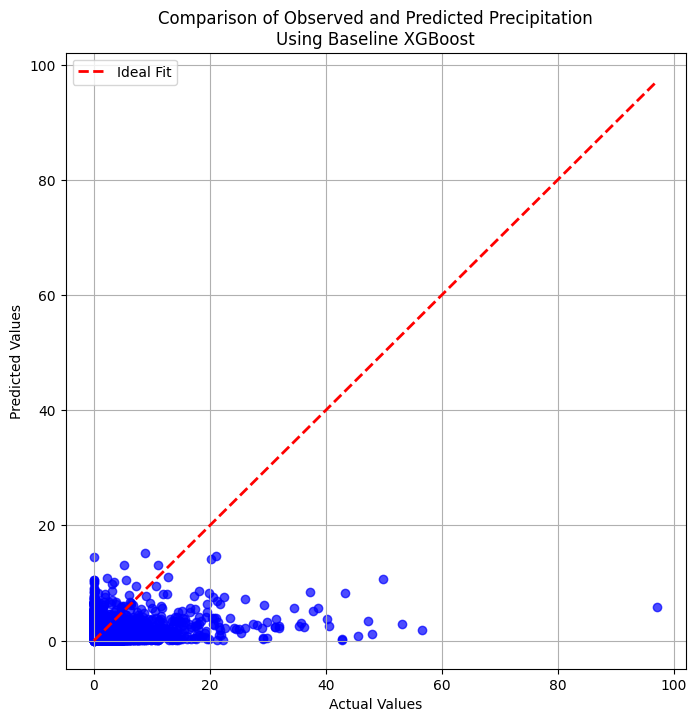

In [9]:
plot_real_vs_predicted(y_test, prec_predictions, save=r'.\fig\xgb_prec_real_vs_predicted_bases_integradas.png')


The model exhibits a strong bias toward low precipitation values, systematically underestimating moderate and extreme rainfall events. This behavior indicates that the model has learned the dominant distribution of the dataset rather than the underlying physical processes associated with precipitation formation.

The current model does NOT understand the physics of rain

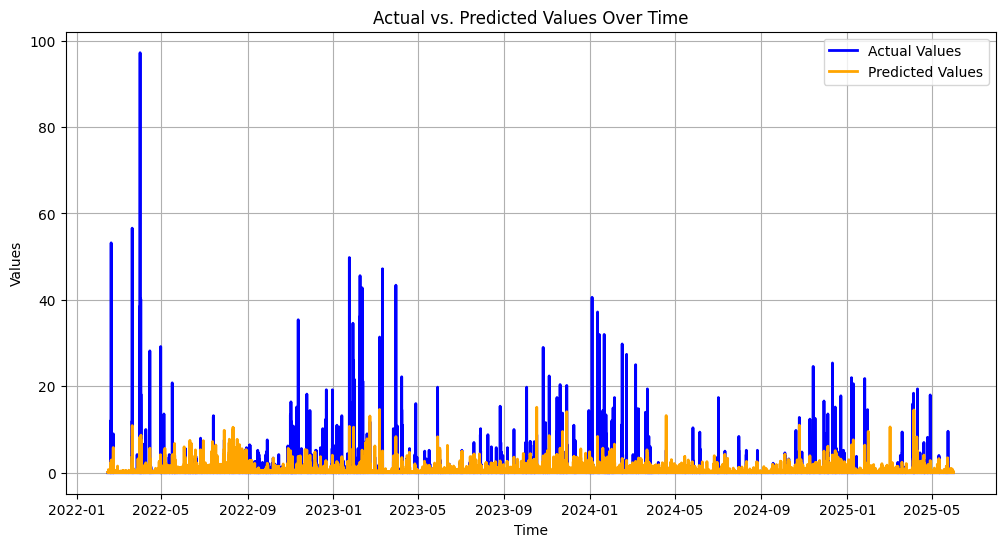

In [10]:
plot_prediction_over_time(y_test, prec_predictions, timestamps_test)


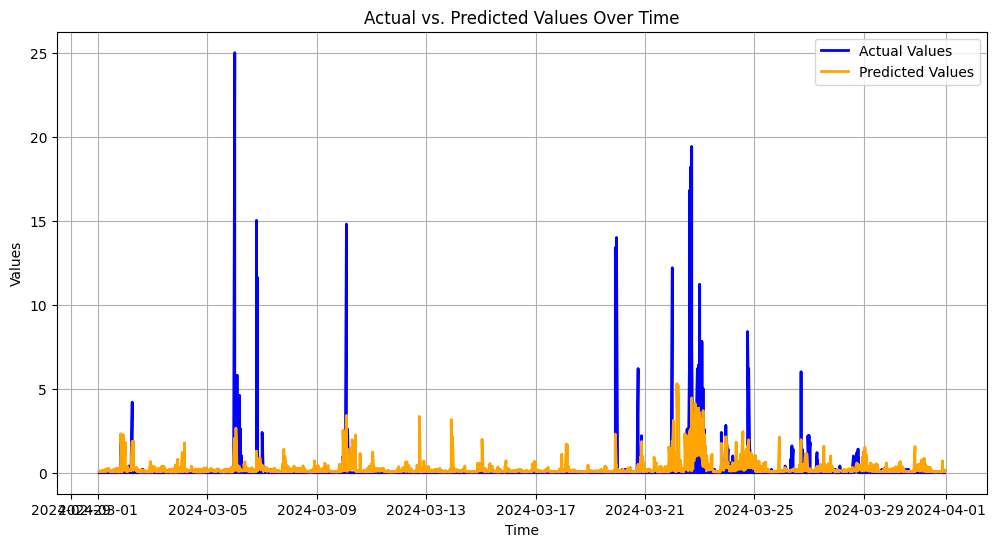

In [11]:
start_date = "2024-03-01 01:00:00"
end_date = "2024-03-31 23:00:00"

plot_prediction_over_time(y_test, prec_predictions, timestamps_test, start_date, end_date, save=r'.\fig\precipitation_march_2024.png')

In [ ]:
import matplotlib.dates as mdates

def plot_daily_prediction_march(y_test, predictions, timestamps, start_date=None, end_date=None, save=False):
    timestamps = pd.to_datetime(timestamps)
    data = pd.DataFrame({'Timestamp': timestamps, 'Actual': y_test, 'Predicted': predictions})

    if start_date:
        data = data[data['Timestamp'] >= pd.to_datetime(start_date)]
    if end_date:
        data = data[data['Timestamp'] <= pd.to_datetime(end_date)]

    plt.figure(figsize=(12, 6))
    plt.plot(data['Timestamp'], data['Actual'], label='Actual Values', color='blue', linewidth=2)
    plt.plot(data['Timestamp'], data['Predicted'], label='Predicted Values', color='orange', linewidth=2)
    
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
    plt.title('Actual vs. Predicted Values - March 2024')
    
    plt.xlabel('Day of Month')
    plt.ylabel('Precipitation (mm/h)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save: 
        plt.savefig(save)
    plt.show()

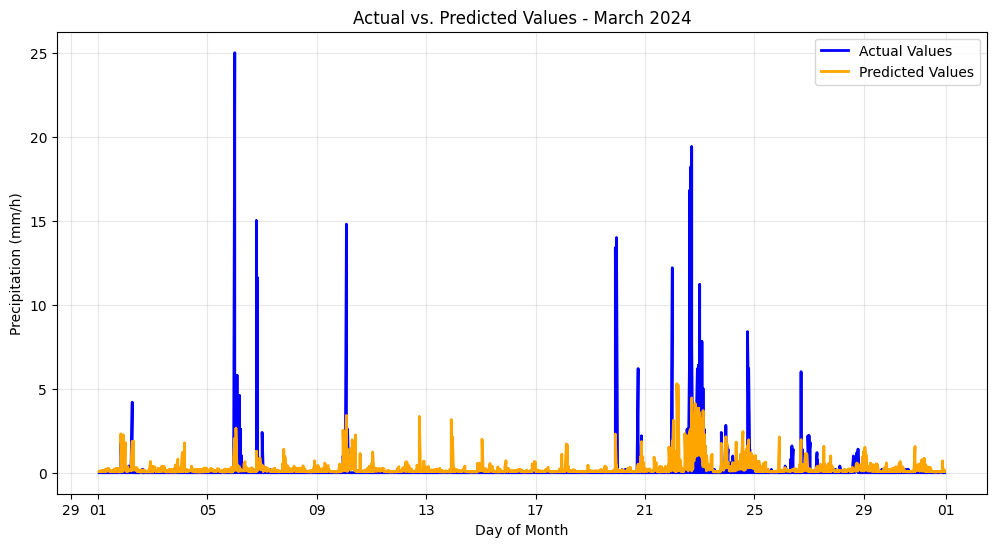

In [13]:
start_date = "2024-03-01 01:00:00"
end_date = "2024-03-31 23:00:00"

# Chamada da nova função
plot_daily_prediction_march(y_test, prec_predictions, timestamps_test, start_date, end_date)

In [14]:
tracker = EmissionsTracker(
    project_name="xgboost shap precipitation 0.8 baseline",
    output_file='./codecarbon_emissions_xgboost_piml_steps.csv',
    log_level = "critical"
)

tracker.start()

explainer = shap.Explainer(prec_model, X_train[:100])
shap_values = explainer(X_test)

emissions: float = tracker.stop()
print(f"emissions={emissions}")

100%|===================| 82737/82966 [06:31<00:01]        

emissions=0.0005683834913447705


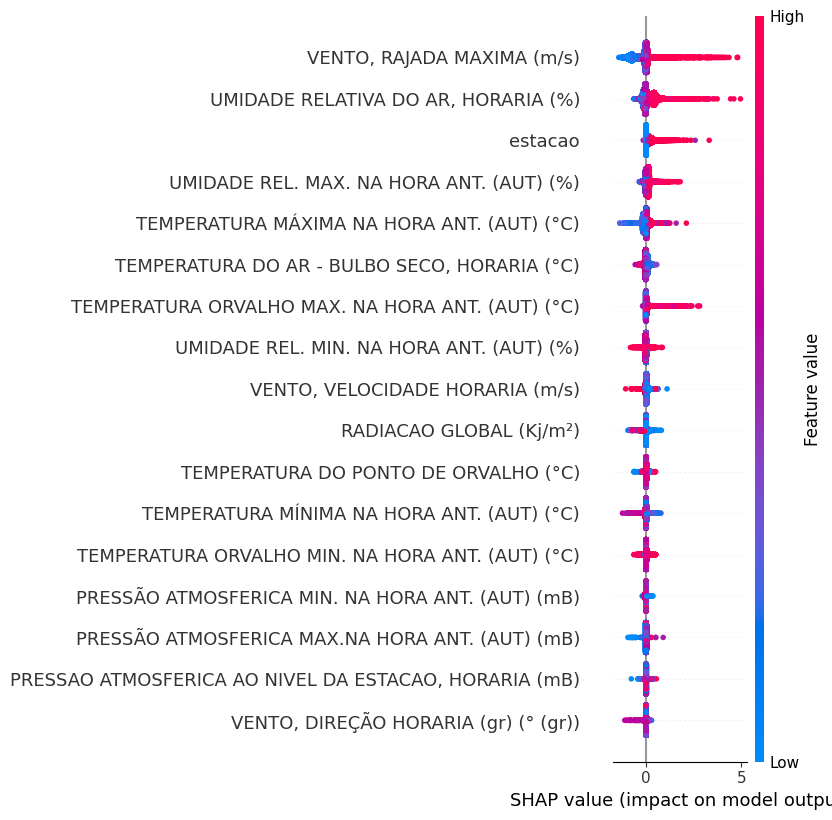

In [15]:
shap.summary_plot(shap_values.values, X_test)

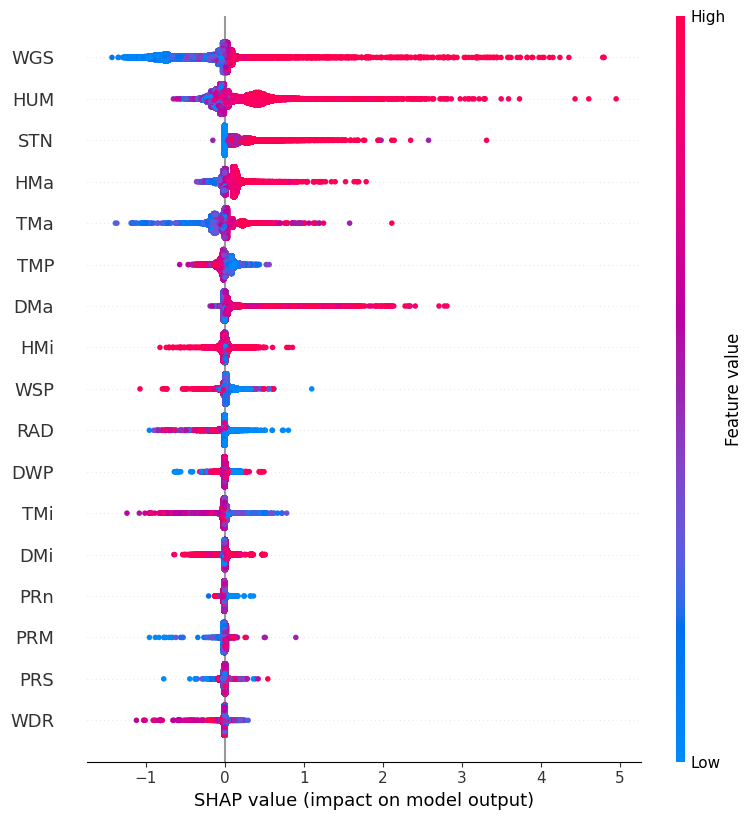

In [16]:
code_translation = {
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'DMa',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'DMi',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'DWP',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'HMa',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'HMi',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'HUM',
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'PRE',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'PRM',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'PRn',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'PRS',
    'RADIACAO GLOBAL (Kj/m²)': 'RAD',
    'estacao': 'STN',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'TMa',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'TMi',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'TMP',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'WDR',
    'VENTO, RAJADA MAXIMA (m/s)': 'WGS',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'WSP'
}

X_test_coded = X_test.rename(columns=code_translation)

shap.summary_plot(shap_values.values, X_test_coded)

The SHAP analysis reveals that, although physically meaningful variables such as wind gust and relative humidity are identified as the most influential predictors, their overall contribution remains limited across most observations. This behavior is consistent with the strong class imbalance in the dataset, where the model predominantly learns patterns associated with non-precipitation events.

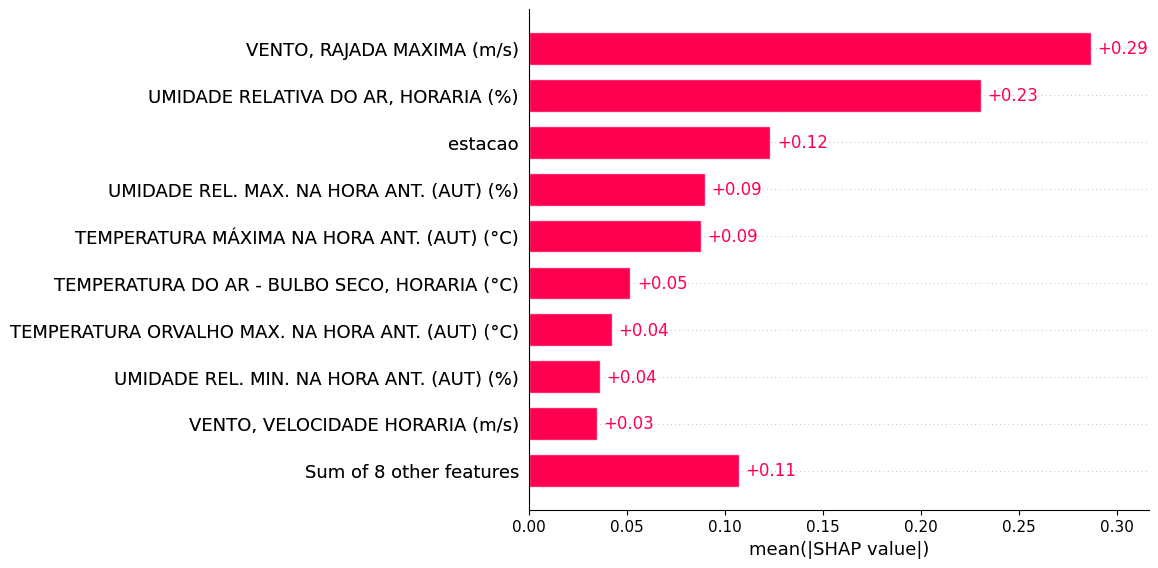

In [17]:
shap.plots.bar(shap_values)

The SHAP global importance analysis indicates that wind gust and relative humidity are the dominant predictors of precipitation. However, the relatively low contribution of other meteorological variables suggests that the model captures only a partial representation of the underlying physical processes.

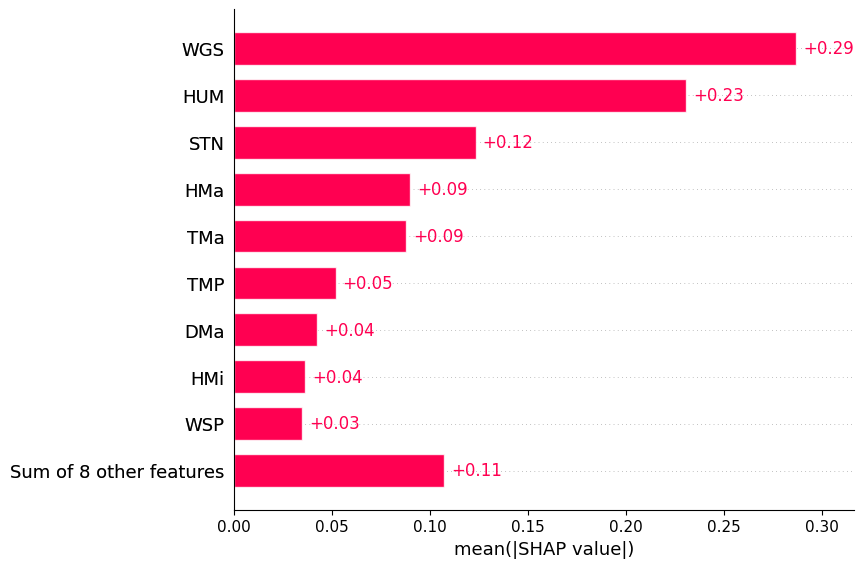

In [ ]:


code_translation = {
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'DMa',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'DMi',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'DWP',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'HMa',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'HMi',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'HUM',
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'PRE',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'PRM',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'PRn',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'PRS',
    'RADIACAO GLOBAL (Kj/m²)': 'RAD',
    'estacao': 'STN',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'TMa',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'TMi',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'TMP',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'WDR',
    'VENTO, RAJADA MAXIMA (m/s)': 'WGS',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'WSP'
}

shap_values_coded = copy.deepcopy(shap_values)

shap_values_coded.feature_names = [code_translation.get(name, name) for name in shap_values_coded.feature_names]

shap.plots.bar(shap_values_coded)

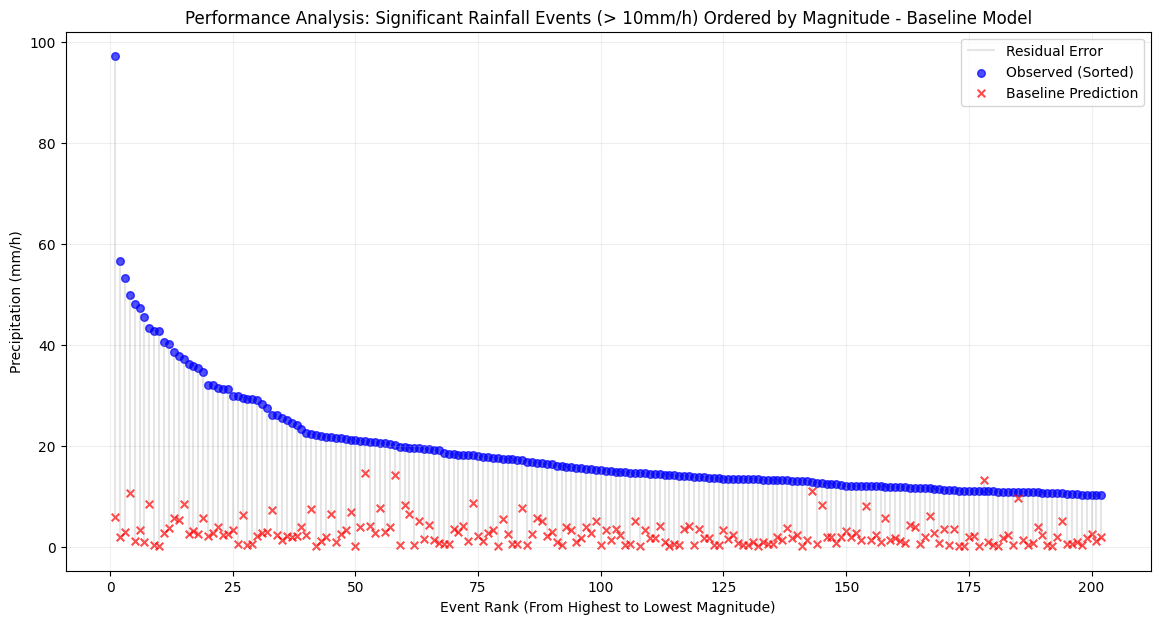

In [21]:
df_results_baseline = pd.DataFrame({
    'Real': y_test.values,
    'Predicted': prec_predictions 
}, index=y_test.index)

df_rank_base = df_results_baseline[df_results_baseline['Real'] > 10].sort_values(by='Real', ascending=False).copy()

df_rank_base['Rank'] = range(1, len(df_rank_base) + 1)

plt.figure(figsize=(14, 7))

plt.vlines(df_rank_base['Rank'], df_rank_base['Real'], df_rank_base['Predicted'], 
           color='gray', alpha=0.2, label='Residual Error')
plt.scatter(df_rank_base['Rank'], df_rank_base['Real'], color='blue', s=30, label='Observed (Sorted)', alpha=0.7)

plt.scatter(df_rank_base['Rank'], df_rank_base['Predicted'], color='red', marker='x', s=30, label='Baseline Prediction', alpha=0.7)

plt.title('Performance Analysis: Significant Rainfall Events (> 10mm/h) Ordered by Magnitude - Baseline Model')
plt.xlabel('Event Rank (From Highest to Lowest Magnitude)')
plt.ylabel('Precipitation (mm/h)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [22]:
mask = y_test > 25  # heavy rain
rmse_heavy = np.sqrt(mean_squared_error(y_test[mask], prec_predictions[mask]))

mask = y_test > 50  # extreme
rmse_extreme = np.sqrt(mean_squared_error(y_test[mask], prec_predictions[mask]))

print(f"rmse_heavy = {rmse_heavy}")
print(f"rmse_heavy = {rmse_extreme}")

rmse_heavy = 36.894251127993996
rmse_heavy = 68.00931860350268
